## Customer Clustering 

In [23]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt 
import pandas as pd
%matplotlib inline

In [24]:
df = pd.read_csv('store_customers.csv')

In [36]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1000,M,39.0,59.9,58.0
1,1001,M,34.0,48.4,37.0
2,1002,F,40.0,70.5,26.0
3,1003,F,47.0,81.1,30.0
4,1004,F,33.0,42.1,58.0


In [37]:
df.fillna(df.median(numeric_only=True), inplace=True)

In [38]:
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

In [39]:
X

,Age,Annual Income (k$),Spending Score (1-100)
0,39.0,59.9,58.0
1,34.0,48.4,37.0
2,40.0,70.5,26.0
3,47.0,81.1,30.0
4,33.0,42.1,58.0
...,...,...,...
995,80.0,133.3,1.0
996,44.0,82.6,40.0
997,46.0,67.7,26.0
998,28.0,45.7,59.0


C:\Users\Vaibhav Bhadoriya\AppData\Local\Temp\ipykernel_16152\2475479750.py:1: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(df['Annual Income (k$)'],


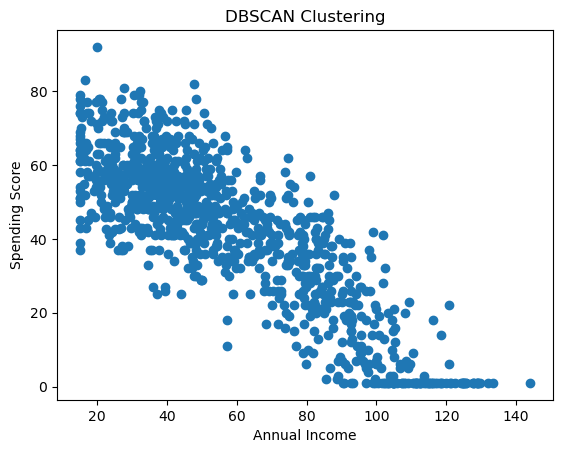

In [40]:
plt.scatter(df['Annual Income (k$)'],
            df['Spending Score (1-100)'],
            cmap='viridis')

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("DBSCAN Clustering")
plt.show()

In [41]:
## Standardization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [43]:
X.isnull().sum() ## Missing Values

Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [44]:
dbscan = DBSCAN(eps=0.5, min_samples=5)
clusters = dbscan.fit_predict(X_scaled)

df['Cluster'] = clusters

In [46]:
print(df['Cluster'].value_counts())

Cluster
 0    995
-1      5
Name: count, dtype: int64


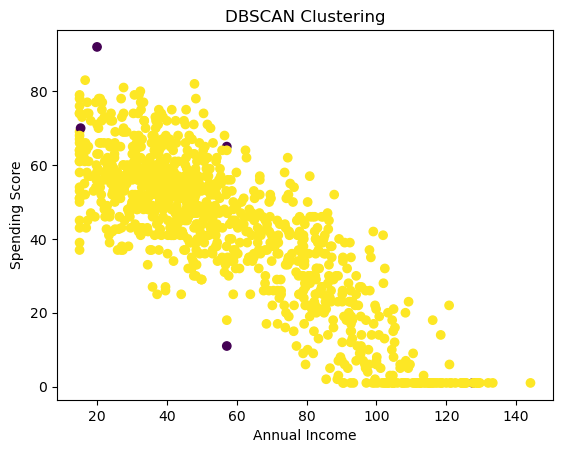

In [45]:
import matplotlib.pyplot as plt

plt.scatter(df['Annual Income (k$)'],
            df['Spending Score (1-100)'],
            c=df['Cluster'],
            cmap='viridis')

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("DBSCAN Clustering")
plt.show()